<h10> Part B — Predictive modeling, continuing from the same cleaned data </h10>

In [25]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
# Train-test split
from sklearn.model_selection import train_test_split, GridSearchCV

# Encoding categorical variables
from sklearn.preprocessing import OneHotEncoder

# Scaling numerical variables
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier

# Classification Metrics
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay, mean_absolute_error,
                             mean_squared_error, r2_score)

df_titanic = pd.read_csv('titanic.csv')
df_titanic.head(5)
df_titanic.columns.tolist()
df_titanic.drop(columns='Unnamed: 0', inplace=True)
df_titanic.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone',
 'age_z',
 'fare_z']

In [3]:
'''
Task-7:
Split the data into train/test sets first, using a stratified split 
(justify why stratification matters given the class balance you observed in Task 1). 
Use survived as the classification target.
'''
df_titanic.columns.tolist()

print("Target distribution:")
print(df_titanic['survived'].value_counts())
print(f"Survival Rate: {df_titanic['survived'].mean():.1%}")
print(f"Death Rate: {1-df_titanic['survived'].mean():.1%}")

# feature selection - for Model: Logistic regression / Decision Tree / Random Forest
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

# Create a clean working copy
data = df_titanic[features + [target]].copy()
print(f"Working dataset: {data.shape}")
print(f"\nMissing values:")
print(data.isnull().sum())

Target distribution:
survived
0    549
1    340
Name: count, dtype: int64
Survival Rate: 38.2%
Death Rate: 61.8%
Working dataset: (889, 8)

Missing values:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [5]:
'''
Task-8
Preprocessing (fit on training data only): handle missing values in the columns 
you use (you do not need to match your Task 2 strategy exactly, but state your 
choice), encode categorical columns (sex, embarked) with label or one-hot encoding, 
and scale numeric features with StandardScaler. Every preprocessing step (imputer, 
encoder, scaler) must be fit only on the training split, then applied in transform-only 
mode to the test split — never fit or refit any preprocessing step on the test data or 
on the full pre-split dataset, since that leaks test-set information into training. It is 
strongly recommended you implement this with a scikit-learn Pipeline/ColumnTransformer 
(a ColumnTransformer for per-column imputing/encoding/scaling, wrapped in a Pipeline with 
the final estimator) so the fit-on-train / transform-on-test separation is enforced 
structurally rather than left for you to remember by hand.
'''
# Missing values in working dataset
print(f"\nMissing values:")
print(data.isnull().sum())

# One-hot encode categorical features
data_encoded = pd.get_dummies(data, columns=['sex', 'embarked'], drop_first=True)

print(f"Shape after encoding: {data_encoded.shape}")
print(f"\nColumns:")
print(data_encoded.columns.tolist())
data_encoded.head()

# Separate features and target
X = data_encoded.drop(target, axis=1)
y = data_encoded[target]

# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set:     {X_test.shape[0]} rows")
print(f"\nTraining survival rate: {y_train.mean():.1%}")
print(f"Test survival rate:     {y_test.mean():.1%}")
# Scaling numerical columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train, transform train
X_test_scaled = scaler.transform(X_test)          # only transform test (no fit!)

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled training data (first 3 rows):")
X_train_scaled.head(3)

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

print("Model Trained")
print(f"\n Coefficients shape: {lr_model.coef_.shape}")
print(f"Intercept: {lr_model.intercept_[0]:.4f}")

# Future predictions
probabilities = lr_model.predict_proba(X_test_scaled)
probabilities

# Predicted values
predicitons = lr_model.predict(X_test_scaled)
predicitons


Missing values:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64
Shape after encoding: (889, 9)

Columns:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']
Training set: 711 rows
Test set:     178 rows

Training survival rate: 38.3%
Test survival rate:     38.2%
Scaled training data (first 3 rows):
Model Trained

 Coefficients shape: (1, 8)
Intercept: -0.6462


array([0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0,
       1, 0])

In [6]:
y_test

159    0
125    0
427    0
421    0
564    0
      ..
39     1
90     0
881    0
851    1
636    0
Name: survived, Length: 178, dtype: int64

In [7]:
'''
Task-9
Train three classifiers on the same train/test split: Logistic Regression, Decision Tree, 
and Random Forest. For the Decision Tree, additionally render it with plot_tree, labeling 
feature names and class names.
'''
data_encoded.shape
data_encoded.columns

# Drop duplicates
data_encoded = data_encoded.drop_duplicates()
print(data_encoded.shape)

# Building Decision Tree on the same dataset
tree_model = DecisionTreeClassifier(
    criterion= "gini", # Same thing as Gini Impurity. SK learn default value
    max_depth = 4, # Depth of the tree
    min_samples_leaf= 10, # Number of samples at the leaf node
    random_state = 42
)

tree_model.fit(X_train, y_train)

(778, 9)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",4
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples i

In [8]:
print("Decision Tree model trained!")
print(f"\n Tree depth: {tree_model.get_depth()}")
print(f"\n Tree leaves: {tree_model.get_n_leaves()}")
print(f"\n Number of features used: {tree_model.n_features_in_}")

Decision Tree model trained!

 Tree depth: 4

 Tree leaves: 13

 Number of features used: 8


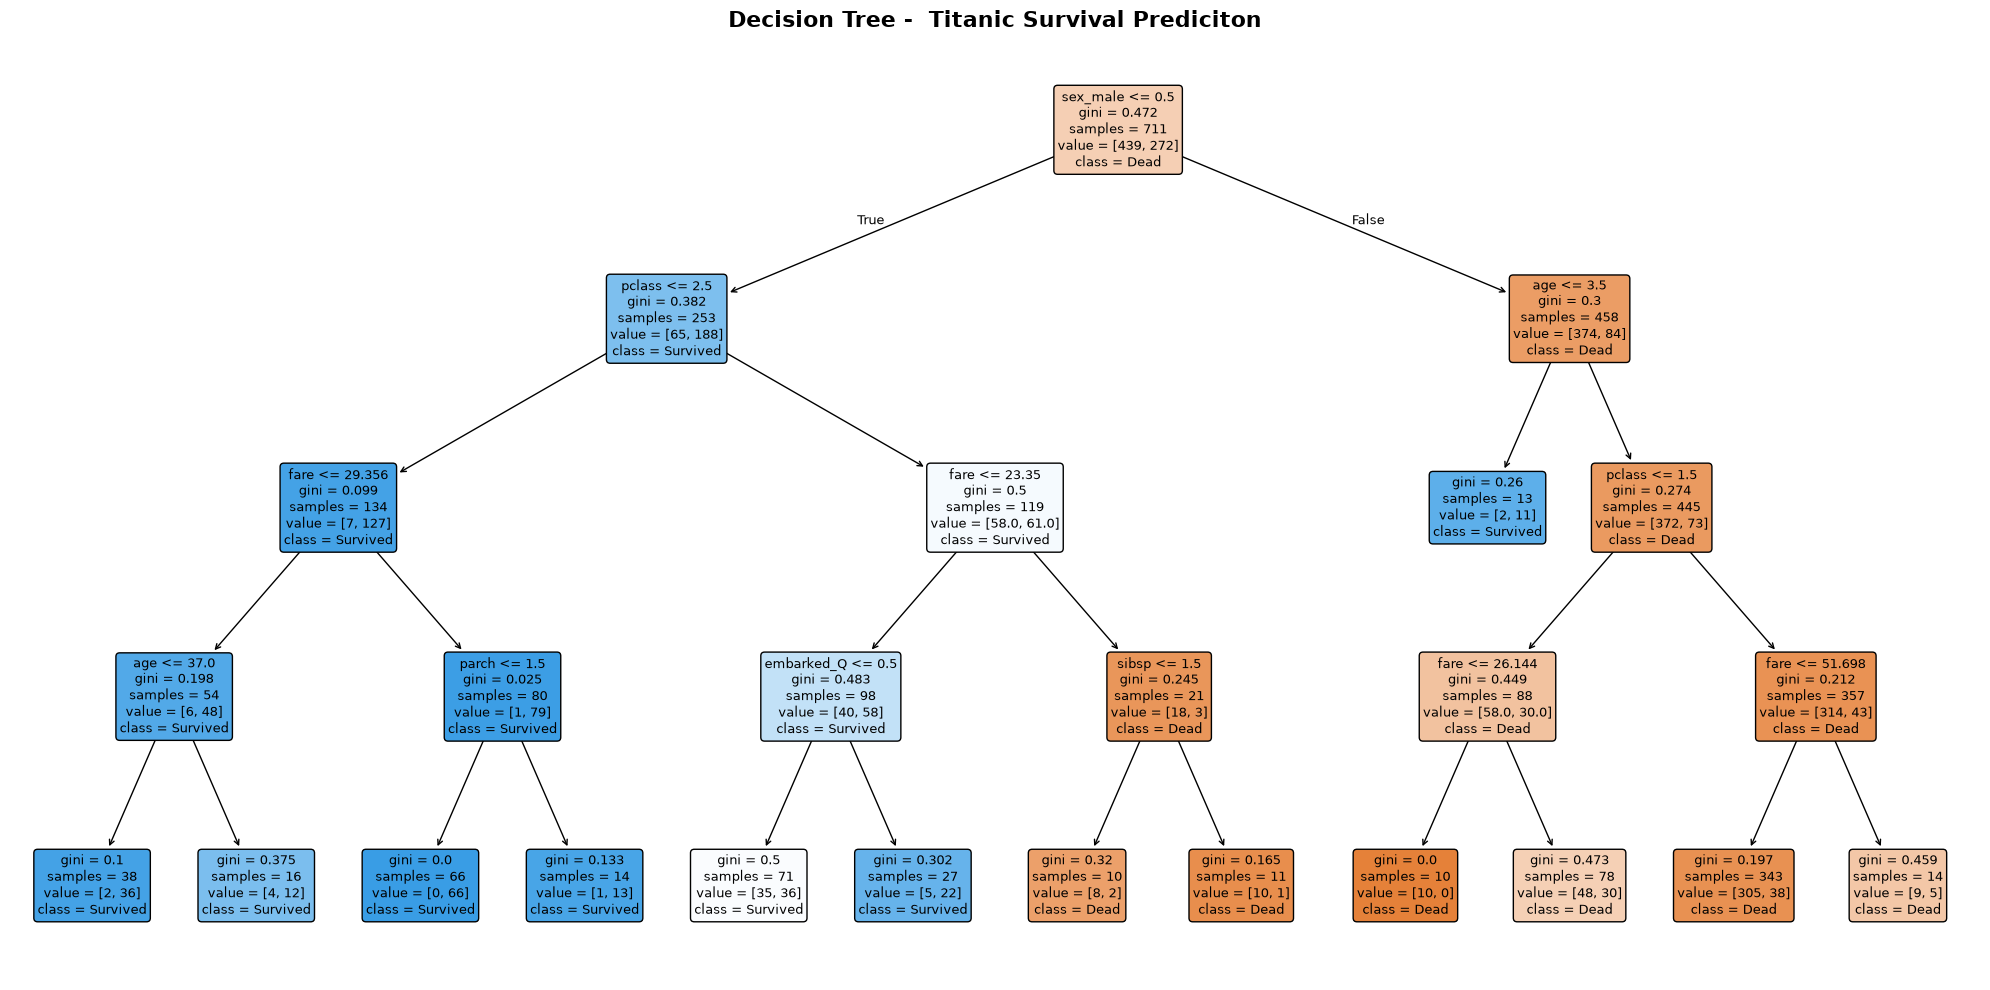

|--- sex_male <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 29.36
|   |   |   |--- age <= 37.00
|   |   |   |   |--- class: 1
|   |   |   |--- age >  37.00
|   |   |   |   |--- class: 1
|   |   |--- fare >  29.36
|   |   |   |--- parch <= 1.50
|   |   |   |   |--- class: 1
|   |   |   |--- parch >  1.50
|   |   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 23.35
|   |   |   |--- embarked_Q <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- embarked_Q >  0.50
|   |   |   |   |--- class: 1
|   |   |--- fare >  23.35
|   |   |   |--- sibsp <= 1.50
|   |   |   |   |--- class: 0
|   |   |   |--- sibsp >  1.50
|   |   |   |   |--- class: 0
|--- sex_male >  0.50
|   |--- age <= 3.50
|   |   |--- class: 1
|   |--- age >  3.50
|   |   |--- pclass <= 1.50
|   |   |   |--- fare <= 26.14
|   |   |   |   |--- class: 0
|   |   |   |--- fare >  26.14
|   |   |   |   |--- class: 0
|   |   |--- pclass >  1.50
|   |   |   |--- fare <= 51.70
|   |   |   |   |--- class: 0
|

In [9]:
# Rendering Decision Tree with Plot_tree and labeling feature names
fix, ax = plt.subplots(figsize=(20, 10))

plot_tree(tree_model,
          feature_names = X.columns.tolist(),
          class_names = ['Dead', 'Survived'],
          filled = True, # Coloring the nodes by majortiy calss)
          rounded = True,
          fontsize = 9,
          ax = ax
)

ax.set_title("Decision Tree -  Titanic Survival Prediciton",
             fontsize = 16, fontweight = 'bold')
plt.tight_layout()
plt.show()

tree_rules = export_text(tree_model, feature_names=X.columns.tolist())
print(tree_rules)

In [10]:
# Building Random forest model on the same dataset
rf = RandomForestClassifier(
    n_estimators = 200, # Number of tres that we are building
    max_depth = None, # letting trees grow deep
    max_features = 'sqrt', # square root of n features per split.
    random_state = 42,
    n_jobs = -1, # You are saying that need to do parallel processing
)

rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [17]:
''' 
Task-10
Evaluate all three models with: a confusion matrix, accuracy, 
precision, recall, F1 score, and an ROC curve with AUC. Present 
these side by side in a single comparison table.
'''
# Accuracy metrics on all three models
y_pred_lr = lr_model.predict(X_test)
y_prob_lr = lr_model.predict_proba(X_test)[:,1]

print(f"Logistic Regression (default settings)")

print("="*45)
print(f"  Train Accuracy:  {lr_model.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:   {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Precision:       {precision_score(y_test, y_pred_lr):.4f}")
print(f"  Recall:          {recall_score(y_test, y_pred_lr):.4f}")
print(f"  F1 Score:        {f1_score(y_test, y_pred_lr):.4f}")
print(f"  ROC-AUC:         {roc_auc_score(y_test, y_pred_lr):.4f}")

y_pred_dt = tree_model.predict(X_test)
y_prob_dt = tree_model.predict_proba(X_test)[:,1]

print(f"Decision Tree (default settings)")

print("="*45)
print(f"  Train Accuracy:  {tree_model.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:   {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  Precision:       {precision_score(y_test, y_pred_dt):.4f}")
print(f"  Recall:          {recall_score(y_test, y_pred_dt):.4f}")
print(f"  F1 Score:        {f1_score(y_test, y_pred_dt):.4f}")
print(f"  ROC-AUC:         {roc_auc_score(y_test, y_pred_dt):.4f}")

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print(f"Random Forest Tree (200 trees, default settings)")

print("="*45)
print(f"  Train Accuracy:  {rf.score(X_train, y_train):.4f}")
print(f"  Test Accuracy:   {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Precision:       {precision_score(y_test, y_pred_rf):.4f}")
print(f"  Recall:          {recall_score(y_test, y_pred_rf):.4f}")
print(f"  F1 Score:        {f1_score(y_test, y_pred_rf):.4f}")
print(f"  ROC-AUC:         {roc_auc_score(y_test, y_pred_rf):.4f}")



Logistic Regression (default settings)
  Train Accuracy:  0.6428
  Test Accuracy:   0.6292
  Precision:       0.6667
  Recall:          0.0588
  F1 Score:        0.1081
  ROC-AUC:         0.5203
Decision Tree (default settings)
  Train Accuracy:  0.8242
  Test Accuracy:   0.7978
  Precision:       0.7759
  Recall:          0.6618
  F1 Score:        0.7143
  ROC-AUC:         0.7718
Random Forest Tree (200 trees, default settings)
  Train Accuracy:  0.9859
  Test Accuracy:   0.8034
  Precision:       0.7391
  Recall:          0.7500
  F1 Score:        0.7445
  ROC-AUC:         0.7932


In [18]:
''' 
Task-11
Imbalance handling comparison: report survived/not-survived class balance, 
then retrain (any one of the three models is enough for this sub-task) three 
ways — (a) baseline/no handling, (b) class_weight='balanced', 
(c) SMOTE oversampling applied only to the training fold (to avoid leakage) 
— and compare precision/recall/F1 across the three variants, with a short 
written conclusion on which imbalance strategy worked best and why.
'''
from imblearn.over_sampling import SMOTE

class_counts = y.value_counts().sort_index()
print(f"Not Survived (0): {class_counts[0]}")
print(f"Survived (1):     {class_counts[1]}")

print(f"Not Survived: {class_counts[0] / len(y) * 100:.2f}%")
print(f"Survived:     {class_counts[1] / len(y) * 100:.2f}%")

# Model A — Baseline / No imbalance handling
model_baseline = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_baseline.fit(X_train, y_train)

precision_baseline = precision_score(
    y_test,
    y_pred_lr
)

recall_baseline = recall_score(
    y_test,
    y_pred_lr
)

f1_baseline = f1_score(
    y_test,
    y_pred_lr
)

# Model B — class_weight='balanced'
y_pred_baseline = model_baseline.predict(X_test)
model_balanced = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

#accuracy metrics
precision_balanced = precision_score(
    y_test,
    y_pred_balanced
)

recall_balanced = recall_score(
    y_test,
    y_pred_balanced
)

f1_balanced = f1_score(
    y_test,
    y_pred_balanced
)

# Model C — SMOTE
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Check the new training balance
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Train the model
model_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_smote.fit(
    X_train_smote,
    y_train_smote
)

y_pred_smote = model_smote.predict(X_test)

# Calculate metrics
precision_smote = precision_score(
    y_test,
    y_pred_smote
)

recall_smote = recall_score(
    y_test,
    y_pred_smote
)

f1_smote = f1_score(
    y_test,
    y_pred_smote
)

# Comparing all the three approaches
results = pd.DataFrame({
    'Method': [
        'Baseline',
        'Class Weight Balanced',
        'SMOTE'
    ],
    'Precision': [
        precision_baseline,
        precision_balanced,
        precision_smote
    ],
    'Recall': [
        recall_baseline,
        recall_balanced,
        recall_smote
    ],
    'F1 Score': [
        f1_baseline,
        f1_balanced,
        f1_smote
    ]
})

print(results.round(4))

Not Survived (0): 549
Survived (1):     340
Not Survived: 61.75%
Survived:     38.25%
Before SMOTE:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE:
survived
1    439
0    439
Name: count, dtype: int64
                  Method  Precision  Recall  F1 Score
0               Baseline     0.6667  0.0588    0.1081
1  Class Weight Balanced     0.7183  0.7500    0.7338
2                  SMOTE     0.7222  0.7647    0.7429


In-case of SMOTE and Class Wieght Balanced model - both Precision and recall values increased and at the same F1 score also increased

In [21]:
''' 
Task-12
Hyperparameter tuning: run GridSearchCV over the Random Forest's 
n_estimators, max_depth, and max_features, report the best parameter combination 
and the corresponding out-of-bag (OOB) score. Because oob_score_ is only populated 
when oob_score=True is passed at construction time, you must construct 
the estimator as RandomForestClassifier(oob_score=True, ...) (together with 
your other chosen/tuned parameters) — otherwise the OOB score will not be 
available to report.
'''
# 1. Create Random Forest with OOB enabled
rf = RandomForestClassifier(
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

# 2. Define hyperparameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'max_features': ['sqrt', 'log2']
}

# 3. Create GridSearchCV
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# 4. Fit GridSearchCV on training data
grid_search.fit(X_train, y_train)

# 5. Best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# 6. Best cross-validation score
print("\nBest CV F1 Score:")
print(grid_search.best_score_)

# Get oob score
oob_score=True

best_rf = grid_search.best_estimator_

print("\nBest OOB Score:")
print(best_rf.oob_score_)

print("===== RANDOM FOREST GRID SEARCH RESULTS =====")

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest CV F1 Score:")
print(round(grid_search.best_score_, 4))

print("\nOOB Score:")
print(round(best_rf.oob_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits


Best Parameters:
{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}

Best CV F1 Score:
0.745902856808766


In [23]:
''' 
Task-13
Regression side-task: using the same dataset, predict fare from the other 
available features with a multivariate linear regression. Report MAE, RMSE, 
R², and Adjusted R², and produce a residual plot, stating in writing whether 
it shows heteroscedasticity (a non-random spread of residuals).
'''
X = df_titanic.drop(columns='fare')
y = df_titanic['fare']

X = pd.get_dummies(X, drop_first=True)

print(X.isnull().sum())
print(y.isnull().sum())

survived                   0
pclass                     0
age                        0
sibsp                      0
parch                      0
adult_male                 0
alone                      0
age_z                      0
fare_z                     0
sex_male                   0
embarked_Q                 0
embarked_S                 0
class_Second               0
class_Third                0
who_man                    0
who_woman                  0
deck_B                     0
deck_C                     0
deck_D                     0
deck_E                     0
deck_F                     0
deck_G                     0
embark_town_Queenstown     0
embark_town_Southampton    0
alive_yes                  0
dtype: int64
0


In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

r2 = r2_score(y_test, y_pred)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

# Calculate Adjusted R2
n = X_test.shape[0]
p = X_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1) / (n - p - 1)
)

print(f"Adjusted R² : {adjusted_r2:.4f}")

MAE  : 0.0000
RMSE : 0.0000
R²   : 1.0000
Adjusted R² : 1.0000


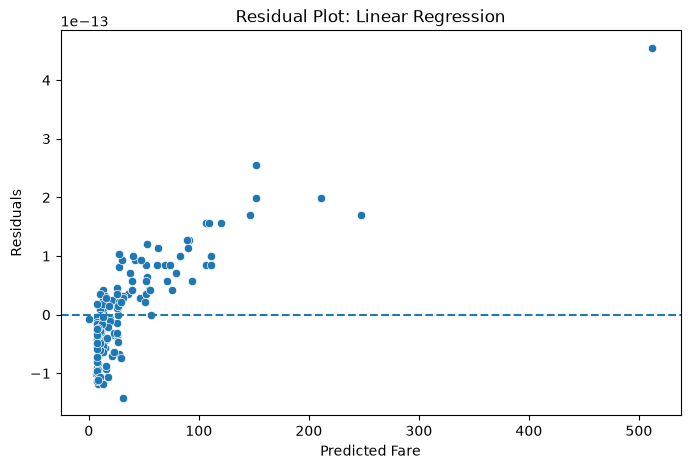

In [29]:
# Residual Plot
# Residual = Actual Fare - Predicted Fare
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot: Linear Regression")

plt.show()

In [30]:
print("===== LINEAR REGRESSION: FARE PREDICTION =====")

print(f"MAE          : {mae:.4f}")
print(f"RMSE         : {rmse:.4f}")
print(f"R²           : {r2:.4f}")
print(f"Adjusted R²  : {adjusted_r2:.4f}")

===== LINEAR REGRESSION: FARE PREDICTION =====
MAE          : 0.0000
RMSE         : 0.0000
R²           : 1.0000
Adjusted R²  : 1.0000


In [34]:
'''
Task-14
Write a model comparison table that presents the three classifiers' metrics 
(accuracy, precision, recall, F1, AUC) side by side, and the regression model's 
metrics (MAE, RMSE, R², Adjusted R²) side by side as their own separate columns. 
Classification metrics and regression metrics are on different scales and are not 
directly comparable numbers — the table must present them as two distinct metric 
groups (one per model type), not implied to be on a single shared scale. Add a 3-5 
sentence final written recommendation of which classifier you would deploy and why, 
referencing specific metric values.
'''
classification_results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr),
        'F1': f1_score(y_test, y_pred_lr),
        'AUC': roc_auc_score(y_test, y_prob_lr)
    },

    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Precision': precision_score(y_test, y_pred_dt),
        'Recall': recall_score(y_test, y_pred_dt),
        'F1': f1_score(y_test, y_pred_dt),
        'AUC': roc_auc_score(y_test, y_prob_dt)
    },

    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1': f1_score(y_test, y_pred_rf),
        'AUC': roc_auc_score(y_test, y_prob_rf)
    }
}

# combined table
comparison_table = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    # Classification metrics
    'Classification_Accuracy': [
        classification_results['Logistic Regression']['Accuracy'],
        classification_results['Decision Tree']['Accuracy'],
        classification_results['Random Forest']['Accuracy']
    ],

    'Classification_Precision': [
        classification_results['Logistic Regression']['Precision'],
        classification_results['Decision Tree']['Precision'],
        classification_results['Random Forest']['Precision']
    ],

    'Classification_Recall': [
        classification_results['Logistic Regression']['Recall'],
        classification_results['Decision Tree']['Recall'],
        classification_results['Random Forest']['Recall']
    ],

    'Classification_F1': [
        classification_results['Logistic Regression']['F1'],
        classification_results['Decision Tree']['F1'],
        classification_results['Random Forest']['F1']
    ],

    'Classification_AUC': [
        classification_results['Logistic Regression']['AUC'],
        classification_results['Decision Tree']['AUC'],
        classification_results['Random Forest']['AUC']
    ],

    # Regression metrics
    'Regression_MAE': [mae, None, None],
    'Regression_RMSE': [rmse, None, None],
    'Regression_R²': [r2, None, None],
    'Regression_Adjusted_R²': [adjusted_r2, None, None]
})

print(comparison_table.round(4))

ValueError: Classification metrics can't handle a mix of continuous and binary targets

In [38]:
''' 
Task-15
Save your best-performing complete pipeline — the fitted preprocessing steps 
(imputer/encoder/scaler, or your ColumnTransformer) together with the final 
estimator, as a single combined object (e.g. a scikit-learn Pipeline) — to 
disk using joblib.dump(full_pipeline, ...). Do not save the bare estimator 
alone: the saved artifact must be usable end-to-end on raw, unpreprocessed 
new data. Include a short script/cell that reloads it with joblib.load and 
confirms it still predicts correctly on raw input.
'''
#import pandas as pd
import joblib

#from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
#from sklearn.preprocessing import OneHotEncoder, StandardScaler
#from sklearn.ensemble import RandomForestClassifier

X = df_titanic.drop(columns='survived')
y = df_titanic['survived']

numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

categorical_features = X.select_dtypes(
    include=['object', 'category', 'bool']
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

final_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', final_model)
])

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

full_pipeline.fit(X_train, y_train)

y_pred = full_pipeline.predict(X_test)

print("Predictions:")
print(y_pred[:10])

# check accuracy score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

# Save the complete pipeline
joblib.dump(
    full_pipeline,
    'titanic_best_pipeline.joblib'
)

print("Complete pipeline saved successfully.")

/tmp/ipykernel_1014/143175962.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


Numeric features:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'age_z', 'fare_z']

Categorical features:
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']
Predictions:
[0 0 0 0 0 0 0 1 1 1]
Test Accuracy: 1.0000
Complete pipeline saved successfully.


In [40]:
import joblib

# Reload the pipeline
loaded_pipeline = joblib.load(
    'titanic_best_pipeline.joblib'
)

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [41]:
# Test completely on raw rows
raw_input = X_test.iloc[[0]].copy()

print("RAW INPUT:")
print(raw_input)

prediction = loaded_pipeline.predict(raw_input)

print("\nPREDICTED SURVIVAL:")
print(prediction[0])

RAW INPUT:
     pclass   sex   age  sibsp  parch  fare embarked  class  who  adult_male  \
159       3  male  44.0      0      1  16.1        S  Third  man        True   

    deck  embark_town alive  alone     age_z    fare_z  
159  NaN  Southampton    no  False  1.107773 -0.322062  

PREDICTED SURVIVAL:
0
